In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import sys  

# For notebooks, handle __file__ not being defined
try:
    project_root = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
except NameError:
    # When running in notebook, __file__ is not defined
    # Get the notebook's directory and go up one level to project root
    project_root = os.path.dirname(os.getcwd())

sys.path.append(project_root)
from configs.paths import Paths

In [7]:
# read input features
df = pd.read_csv(Paths.INPUT_FEATURES_FILE)
df.head()

,Date,Rented Bike Count,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,Snowfall,Seasons,Holiday
0,1/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday
1,1/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday
2,1/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday
3,1/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday
4,1/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday


In [9]:
# read output features
df_output = pd.read_csv(Paths.OUTPUT_TARGETS_FILE)
print(df_output.head())

  Functioning Day
0             Yes
1             Yes
2             Yes
3             Yes
4             Yes


In [10]:
df.shape

(8760, 13)

In [11]:
df_output.shape

(8760, 1)

In [12]:
df.describe()

,Rented Bike Count,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,Snowfall
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   8760 non-null   str    
 1   Rented Bike Count      8760 non-null   int64  
 2   Hour                   8760 non-null   int64  
 3   Temperature            8760 non-null   float64
 4   Humidity               8760 non-null   int64  
 5   Wind speed             8760 non-null   float64
 6   Visibility             8760 non-null   int64  
 7   Dew point temperature  8760 non-null   float64
 8   Solar Radiation        8760 non-null   float64
 9   Rainfall               8760 non-null   float64
 10  Snowfall               8760 non-null   float64
 11  Seasons                8760 non-null   str    
 12  Holiday                8760 non-null   str    
dtypes: float64(6), int64(4), str(3)
memory usage: 1.1 MB


In [14]:
new_cols = ["date","rented_bike_count","hour","temperature","humidity","windspeed","visibility","dew_point_temperature","solar_radiation","rainfall","snowfall","seasons","holiday"]
# rename columns in df
df.columns = new_cols
# print new column names
print(df.columns)

Index(['date', 'rented_bike_count', 'hour', 'temperature', 'humidity',
       'windspeed', 'visibility', 'dew_point_temperature', 'solar_radiation',
       'rainfall', 'snowfall', 'seasons', 'holiday'],
      dtype='str')


*Identify categorical column unique values*

In [16]:
categorical_cols = ["seasons", "holiday", "date"]
numeric_cols = ["temperature", "humidity", "windspeed", "visibility", "dew_point_temperature", "solar_radiation", "rainfall", "snowfall","hour","rented_bike_count"]

In [17]:
print(df[categorical_cols].nunique())

seasons      4
holiday      2
date       365
dtype: int64


In [18]:
for cols in categorical_cols:
    if cols == "date":
        continue  # Skip printing unique values for 'date' column       
    print(f"Unique values in {cols}: {df[cols].unique()}")

Unique values in seasons: <ArrowStringArray>
['Winter', 'Spring', 'Summer', 'Autumn']
Length: 4, dtype: str
Unique values in holiday: <ArrowStringArray>
['No Holiday', 'Holiday']
Length: 2, dtype: str


1. Map "No Holiday" to "0" and "Holiday" to 1.
2. Rename column "holiday" to "is_holiday".

*Check for class imbalance*

In [19]:
df_output["Functioning Day"].value_counts().reset_index()

,Functioning Day,count
0,Yes,8465
1,No,295


In [20]:
yes_percent = (8465 / df_output.shape[0]) * 100
no_percent = (df_output.shape[0] - 8465) / df_output.shape[0] * 100
print(f"yes count: {yes_percent:.2f}%")
print(f"no count: {no_percent:.2f}%")

yes count: 96.63%
no count: 3.37%


There's a class imbalance. "Yes" value has 96.63% of majority.
1. Use SMOTE to balance the class of "Yes" and "No"
2. Map "Yes" and "no" to "0" and "1" respectively

*find if null values*

In [21]:
df.isnull().sum()

date                     0
rented_bike_count        0
hour                     0
temperature              0
humidity                 0
windspeed                0
visibility               0
dew_point_temperature    0
solar_radiation          0
rainfall                 0
snowfall                 0
seasons                  0
holiday                  0
dtype: int64

In [22]:
df_output.isnull().sum()

Functioning Day    0
dtype: int64

*find if duplicate values*

In [23]:
df.duplicated().sum()

np.int64(0)

In [26]:
df.columns

Index(['date', 'rented_bike_count', 'hour', 'temperature', 'humidity',
       'windspeed', 'visibility', 'dew_point_temperature', 'solar_radiation',
       'rainfall', 'snowfall', 'seasons', 'holiday'],
      dtype='str')

In [38]:
# Total rented bikes
total_rented_bikes = df["rented_bike_count"].sum(axis=0)
print("total rented bikes from december 2017 to december 2018:", total_rented_bikes)

total rented bikes from december 2017 to december 2018: 6172314


In [30]:
df["date"].unique()

<ArrowStringArray>
[ '1/12/2017',  '2/12/2017',  '3/12/2017',  '4/12/2017',  '5/12/2017',
  '6/12/2017',  '7/12/2017',  '8/12/2017',  '9/12/2017', '10/12/2017',
 ...
 '21/11/2018', '22/11/2018', '23/11/2018', '24/11/2018', '25/11/2018',
 '26/11/2018', '27/11/2018', '28/11/2018', '29/11/2018', '30/11/2018']
Length: 365, dtype: str

In [35]:
# convert date column to datetime format
df["date"] = pd.to_datetime(df["date"], format="%d/%m/%Y")
# convert date into "day", "month", "year"
df["day"] = df["date"].dt.day
df["month"] = df["date"].dt.month
df["year"] = df["date"].dt.year 
print(df[["date","day","month","year"]].head(10))

        date  day  month  year
0 2017-12-01    1     12  2017
1 2017-12-01    1     12  2017
2 2017-12-01    1     12  2017
3 2017-12-01    1     12  2017
4 2017-12-01    1     12  2017
5 2017-12-01    1     12  2017
6 2017-12-01    1     12  2017
7 2017-12-01    1     12  2017
8 2017-12-01    1     12  2017
9 2017-12-01    1     12  2017


In [45]:
# add day, month, year columns in numerical_cols list
numeric_cols.extend(["day", "month", "year"])
numeric_cols

['temperature',
 'humidity',
 'windspeed',
 'visibility',
 'dew_point_temperature',
 'solar_radiation',
 'rainfall',
 'snowfall',
 'hour',
 'rented_bike_count',
 'day',
 'month',
 'year']

In [39]:
# sum of number of bikes rented by each month
sum_of_bikes_by_month = df.groupby("month")["rented_bike_count"].sum().reset_index().sort_values(by="rented_bike_count", ascending=False)
print(sum_of_bikes_by_month)

    month  rented_bike_count
5       6             896887
6       7             734460
4       5             707088
8       9             673612
7       8             651887
9      10             650675
3       4             524227
10     11             465715
2       3             380594
11     12             185330
1       2             151833
0       1             150006


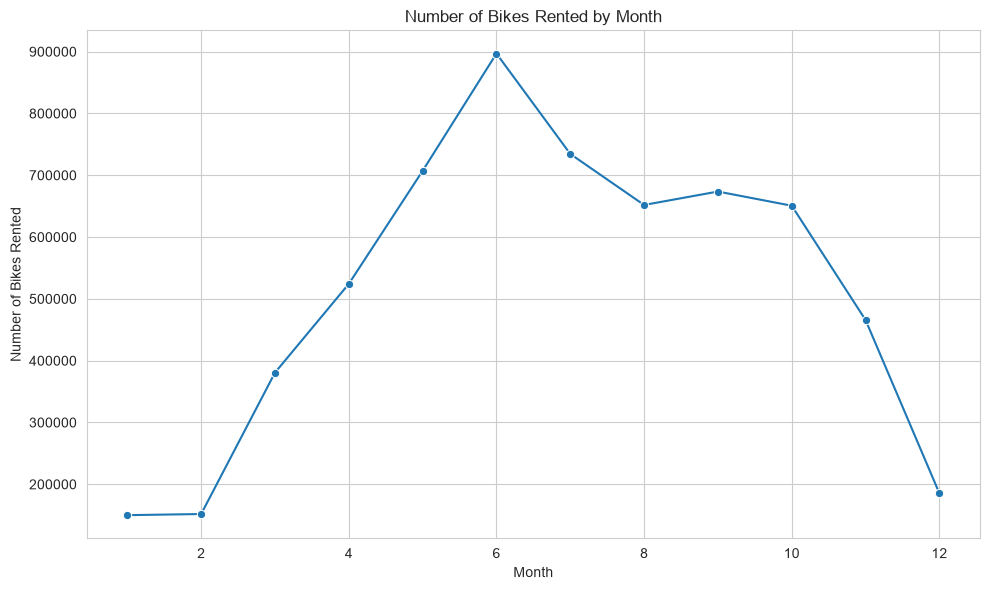

In [40]:
# plot line graph for number of bikes rented by each month
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
sns.lineplot(data=sum_of_bikes_by_month, x="month", y="rented_bike_count", marker="o")
plt.title("Number of Bikes Rented by Month")
plt.xlabel("Month")
plt.ylabel("Number of Bikes Rented")
plt.tight_layout()
plt.show()

In [41]:
# season wise total rented bikes
rented_bikes_by_season = df.groupby("seasons")["rented_bike_count"].sum().reset_index().sort_values(by="rented_bike_count", ascending=False)
rented_bikes_by_season

,seasons,rented_bike_count
2,Summer,2283234
0,Autumn,1790002
1,Spring,1611909
3,Winter,487169


C:\Users\chill\AppData\Local\Temp\ipykernel_35100\137382908.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rented_bikes_by_season, x="seasons", y="rented_bike_count", palette="viridis")


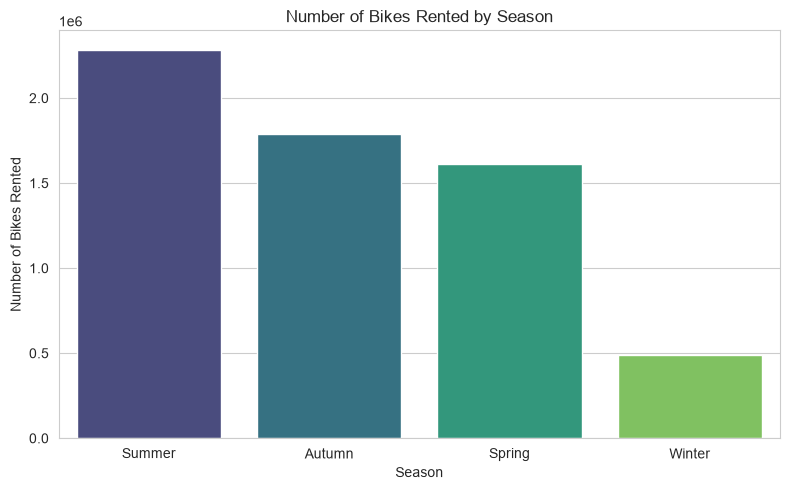

In [43]:
# plot bar graph for number of bikes rented by each season
plt.figure(figsize=(8,5))
sns.set_style("whitegrid")
sns.barplot(data=rented_bikes_by_season, x="seasons", y="rented_bike_count", palette="viridis")
plt.title("Number of Bikes Rented by Season")
plt.xlabel("Season")
plt.ylabel("Number of Bikes Rented")
plt.tight_layout()
plt.show()

In [44]:
# number of bikes rented by holiday
bikes_rented_by_holiday = df.groupby("holiday")["rented_bike_count"].sum().reset_index().sort_values(by="rented_bike_count", ascending=False)
bikes_rented_by_holiday

,holiday,rented_bike_count
1,No Holiday,5956419
0,Holiday,215895


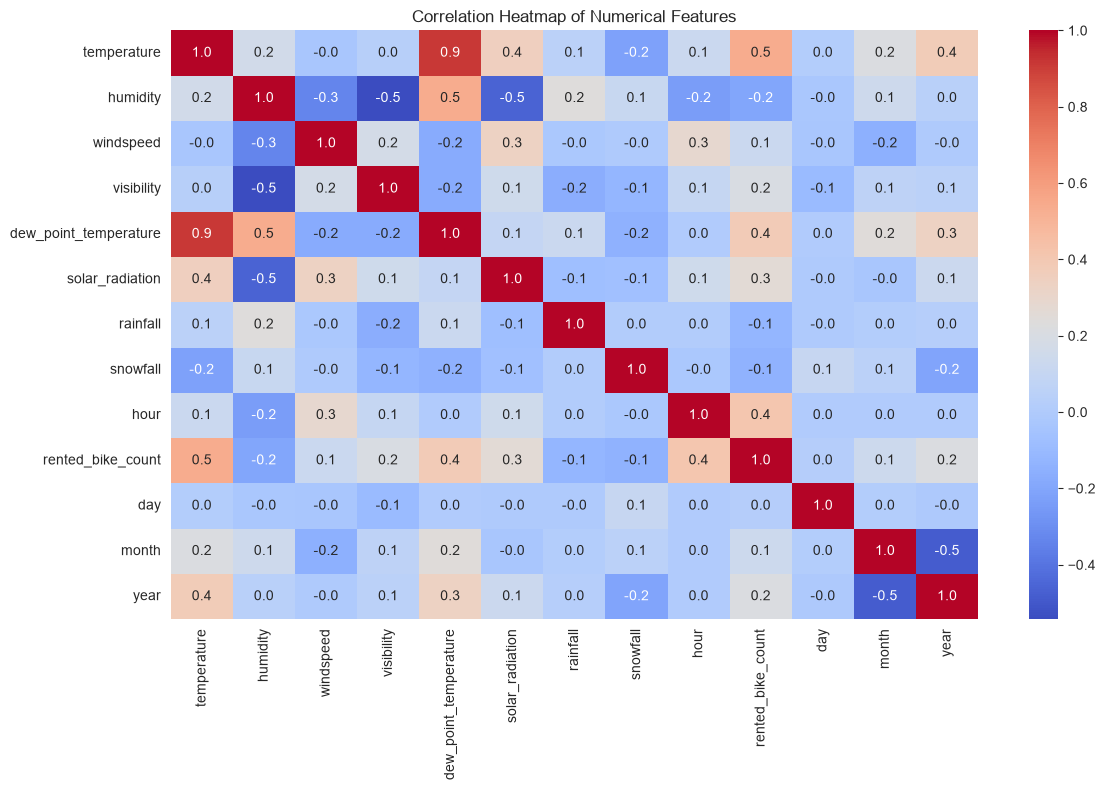

In [46]:
# plot heat map for correlation between numerical columns
plt.figure(figsize=(12, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".1f")
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

In [50]:
# merge input features and output features on date column
df_merged = pd.concat([df, df_output], axis=1)
df_merged.head(6)

,date,rented_bike_count,hour,temperature,humidity,windspeed,visibility,dew_point_temperature,solar_radiation,rainfall,snowfall,seasons,holiday,day,month,year,Functioning Day
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,1,12,2017,Yes
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,1,12,2017,Yes
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,1,12,2017,Yes
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,1,12,2017,Yes
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,1,12,2017,Yes
5,2017-12-01,100,5,-6.4,37,1.5,2000,-18.7,0.0,0.0,0.0,Winter,No Holiday,1,12,2017,Yes


In [51]:
# feature engineering: create new features based on existing ones
df_merged["temp_humidity_interaction"] = df_merged["temperature"] * df_merged["humidity"]
df_merged["temp_windspeed_interaction"] = df_merged["temperature"] * df_merged["windspeed"]
df_merged.head(6)

,date,rented_bike_count,hour,temperature,humidity,windspeed,visibility,dew_point_temperature,solar_radiation,rainfall,snowfall,seasons,holiday,day,month,year,Functioning Day,temp_humidity_interaction,temp_windspeed_interaction
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,1,12,2017,Yes,-192.4,-11.44
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,1,12,2017,Yes,-209.0,-4.40
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,1,12,2017,Yes,-234.0,-6.00
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,1,12,2017,Yes,-248.0,-5.58
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,1,12,2017,Yes,-216.0,-13.80
5,2017-12-01,100,5,-6.4,37,1.5,2000,-18.7,0.0,0.0,0.0,Winter,No Holiday,1,12,2017,Yes,-236.8,-9.60
